DS4002 Image analysis

use master_release_schedule_update4 for baseline, filter for films with valid box office info

In [13]:
import pandas as pd

# 1. Load your dataset
filename = 'MASTER_RELEASE_SCHEDULE_UPDATE4.csv'
df = pd.read_csv(filename)

# 2. Filter the dataset
# We keep rows where at least one of these three columns is NOT null (notna)
# .any(axis=1) returns True if at least one column in that row is True
financial_columns = ['domestic', 'worldwide', 'international']
filtered_df = df[df[financial_columns].notna().any(axis=1)]

# 3. Report the results
original_count = len(df)
filtered_count = len(filtered_df)
removed_count = original_count - filtered_count

print(f"Original entries: {original_count}")
print(f"Entries kept (with financial data): {filtered_count}")
print(f"Entries removed (no financial data): {removed_count}")

# 4. Save the reduced dataset to a new CSV
filtered_df.to_csv('FILTERED_RELEASE_SCHEDULE.csv', index=False)
print("Saved reduced dataset to 'FILTERED_RELEASE_SCHEDULE.csv'")

/var/folders/bc/crsg43752y91kmjz_f8rjgnw0000gn/T/ipykernel_80427/2311257274.py:5: DtypeWarning: Columns (134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357

Original entries: 80079
Entries kept (with financial data): 21795
Entries removed (no financial data): 58284
Saved reduced dataset to 'FILTERED_RELEASE_SCHEDULE.csv'


NOTE: This first portion of the analysis was done on a sample of 1000 posters, which produced vastly different results in terms of the modeling phase, it is included here just for completeness.

Use this dataset to get a random sample of 1000 film posters

In [ ]:
import pandas as pd
import requests
import os
import time
from tqdm import tqdm

# --- Configuration ---
API_KEY = "40b746fe3d756e4c2d54323e530a5911"
INPUT_FILE = "FILTERED_RELEASE_SCHEDULE.csv"
SAVE_DIR = "sampled_posters"
BASE_IMAGE_URL = "https://image.tmdb.org/t/p/w500"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# 1. Load and Filter Dataset
df = pd.read_csv(INPUT_FILE)

# Keep rows where at least one financial column is not null
financial_cols = ['domestic', 'worldwide', 'international']
df_filtered = df[df[financial_cols].notna().any(axis=1)].copy()

# 2. Take a Random Sample of 100
# If the dataset has fewer than 100 rows, it will take all of them
sample_size = min(1000, len(df_filtered))
df_sample = df_filtered.sample(n=sample_size, random_state=42)

print(f"Filtered dataset from {len(df)} to {len(df_filtered)} films with financial data.")
print(f"Proceeding with a random sample of {sample_size} films.")

def get_poster_by_imdb_id(tconst):
    """Uses TMDb Find endpoint to get movie poster via IMDb ID."""
    # The 'find' endpoint is perfect for tconst lookups
    url = f"https://api.themoviedb.org/3/find/{tconst}"
    params = {
        "api_key": API_KEY,
        "external_source": "imdb_id"
    }
    
    try:
        response = requests.get(url, params=params).json()
        # Find results are grouped by type (movie_results, tv_results, etc.)
        movie_results = response.get('movie_results', [])
        
        if movie_results:
            path = movie_results[0].get('poster_path')
            if path:
                return f"{BASE_IMAGE_URL}{path}"
    except Exception as e:
        print(f"Error finding ID {tconst}: {e}")
    return None

# 3. Download Loop
results = []

for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    tconst = row['tconst']
    title = row['primaryTitle']
    
    poster_url = get_poster_by_imdb_id(tconst)
    
    if poster_url:
        # Save filename using tconst to ensure it's unique and valid
        filename = f"{tconst}.jpg"
        save_path = os.path.join(SAVE_DIR, filename)
        
        try:
            img_data = requests.get(poster_url).content
            with open(save_path, 'wb') as f:
                f.write(img_data)
            
            # Record success
            row_data = row.to_dict()
            row_data['local_poster_path'] = save_path
            results.append(row_data)
        except Exception as e:
            print(f"Failed to download {title}: {e}")
    
    # Respect rate limits
    time.sleep(0.1)

# 4. Save the Final Mapping
final_df = pd.DataFrame(results)
final_df.to_csv("SAMPLED_POSTER_METADATA.csv", index=False)
print(f"\nSuccess! {len(final_df)} posters downloaded.")

This code chunk implements an unsupervised machine learning pipeline to quantify the visual aesthetic of movie posters. By converting subjective "art" into objective "data," it allows for statistical testing of color-based hypotheses.

Core Logic:

Image Preprocessing: Uses OpenCV to load posters and resize them to a standard width (200px). This maintains color integrity while significantly reducing the computational load for the clustering algorithm.

K-Means Clustering: Employs the scikit-learn K-Means algorithm to group millions of pixels into k=5 dominant color clusters. This effectively "summarizes" the poster's primary color scheme.

Feature Engineering: Extracts the RGB coordinates for each cluster center and sorts them by frequency, providing a weighted profile of the poster's most prominent hues.

Data Integration: Maps these color palettes back to the original film metadata (indexed by tconst), producing a final dataset (FINAL_ANALYSIS_READY_DATA.csv) ready for correlation analysis with box office revenue and release schedules.

In [ ]:
import cv2
import pandas as pd
import numpy as np
import os
from sklearn.cluster import KMeans
from tqdm import tqdm

# --- Configuration ---
IMAGE_DIR = "sampled_posters"
METADATA_FILE = "SAMPLED_POSTER_METADATA.csv"
CLUSTERS = 5 # Number of dominant colors to find per poster

# Load the metadata we created in the last step
df = pd.read_csv(METADATA_FILE)

def get_dominant_colors(image_path, k=5):
    """Loads an image and returns the k-dominant RGB colors."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # 1. Convert BGR (OpenCV default) to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Resize to speed up processing (200px width is enough for color analysis)
    height, width, _ = img.shape
    new_width = 200
    new_height = int(height * (new_width / width))
    img = cv2.resize(img, (new_width, new_height), interpolation=cv2.INTER_AREA)
    
    # 3. Reshape the image to be a list of pixels
    pixels = img.reshape((-1, 3))
    
    # 4. Cluster pixels using KMeans
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=42)
    kmeans.fit(pixels)
    
    # Get colors (cluster centers) and convert to integer
    colors = kmeans.cluster_centers_.astype(int)
    
    # Sort colors by how frequently they appear (optional but helpful)
    labels = list(kmeans.labels_)
    counts = [labels.count(i) for i in range(k)]
    sorted_colors = [colors[i] for i in np.argsort(counts)[::-1]]
    
    return sorted_colors

# --- Processing Loop ---
print(f"Analyzing color palettes for {len(df)} posters...")
palette_data = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row['local_poster_path']
    
    if os.path.exists(path):
        palette = get_dominant_colors(path, k=CLUSTERS)
        # Store as a list of RGB tuples
        palette_data.append(palette)
    else:
        palette_data.append(None)

# Add the new column and save
df['color_palette_rgb'] = palette_data
df.to_csv("FINAL_ANALYSIS_READY_DATA.csv", index=False)
print("Analysis complete! Palettes saved to 'FINAL_ANALYSIS_READY_DATA.csv'")

NOTE: The following several code chunks attempt to implement various face-recognition systems that do not work, we eventually settle on Retina

This stage of the pipeline quantifies the "human element" of movie posters to test the correlation between star-driven marketing and financial returns.

Logic: The script utilizes the Haar Cascade object detection algorithm via OpenCV. By converting posters to grayscale and applying a multi-scale sliding window, the model identifies rectangular regions that match the visual patterns of human faces.

Data Transformation: Subjective visual density is converted into a discrete numerical variable (face_count).

Merging: This new variable is joined with the existing TMDb metadata and K-Means color clusters, creating a rich, multimodal dataset.

Research Application: This allows for testing whether "ensemble" posters (high face count) correlate with higher Worldwide Revenue compared to minimalist or landscape-focused posters.

In [ ]:
import cv2
import pandas as pd
import os
from tqdm import tqdm

# --- Configuration ---
INPUT_FILE = "FINAL_ANALYSIS_READY_DATA.csv"
OUTPUT_FILE = "COMPLETE_ANALYSIS_DATA.csv"

# Load the XML file for face detection (standard OpenCV feature)
# Note: Ensure 'haarcascade_frontalface_default.xml' is available or use the cv2 path
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 1. Load your existing analysis-ready data
df = pd.read_csv(INPUT_FILE)

def count_faces(image_path):
    """Detects and counts frontal faces in a movie poster."""
    img = cv2.imread(image_path)
    if img is None:
        return 0
    
    # Convert to grayscale for the face detector
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    # scaleFactor: How much the image size is reduced at each image scale
    # minNeighbors: How many neighbors each candidate rectangle should have to retain it
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    return len(faces)

# --- Processing Loop ---
print(f"Detecting faces for {len(df)} posters...")
face_counts = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row['local_poster_path']
    
    if os.path.exists(path):
        count = count_faces(path)
        face_counts.append(count)
    else:
        face_counts.append(0)

# 2. Merge and Save
df['face_count'] = face_counts
df.to_csv(OUTPUT_FILE, index=False)

print(f"Success! Merged data saved to '{OUTPUT_FILE}'.")
print(df[['primaryTitle', 'face_count', 'worldwide']].head())

The above face detection does not seem to work

To address the accuracy limitations of traditional edge-based detection (Haar Cascades), the pipeline was upgraded to use MediaPipe Face Detection, a specialized Short-range BlazeFace model.

Logic: Unlike older methods that rely on simple contrast patterns, this system uses a Single Shot Detector (SSD) architecture optimized for mobile and web real-time performance. This allows it to identify faces with higher precision even when they are partially obscured, rotated, or stylized.

Performance: The model_selection=1 parameter was utilized to optimize for "full-range" detection, ensuring that small background characters and central "floating heads" are both captured in the face_count metric.

Data Integration: The refined counts were merged into the master dataframe, creating a high-fidelity feature set for the final correlation analysis between visual density and box office returns.

In [9]:
import cv2
import mediapipe as mp
import pandas as pd
import os
from tqdm import tqdm
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# --- Configuration ---
INPUT_FILE  = "FINAL_ANALYSIS_READY_DATA.csv"
OUTPUT_FILE = "COMPLETE_ANALYSIS_DATA_V2.csv"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Could not find {INPUT_FILE}.")

# Download the model file if needed (one-time download ~6 MB)
MODEL_PATH = "blaze_face_short_range.tflite"
if not os.path.exists(MODEL_PATH):
    import urllib.request
    url = "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
    print(f"Downloading model to {MODEL_PATH}...")
    urllib.request.urlretrieve(url, MODEL_PATH)

# Build the detector using the new Tasks API
base_options    = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
detector_options = vision.FaceDetectorOptions(
    base_options=base_options,
    min_detection_confidence=0.5
)
face_detector = vision.FaceDetector.create_from_options(detector_options)

df = pd.read_csv(INPUT_FILE)

def count_faces_mediapipe(image_path):
    """Detects faces using the MediaPipe Tasks FaceDetector."""
    img = cv2.imread(image_path)
    if img is None:
        return 0
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Wrap in MediaPipe Image format
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results  = face_detector.detect(mp_image)
    return len(results.detections) if results.detections else 0

# --- Processing Loop (unchanged) ---
print(f"Running face detection for {len(df)} posters...")
face_counts = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row["local_poster_path"]
    face_counts.append(
        count_faces_mediapipe(path)
        if isinstance(path, str) and os.path.exists(path)
        else 0
    )

df["face_count_refined"] = face_counts
df.to_csv(OUTPUT_FILE, index=False)
face_detector.close()
print(f"Success! Saved to '{OUTPUT_FILE}'.")


FileNotFoundError: Could not find FINAL_ANALYSIS_READY_DATA.csv.

above face detection system also is not accurate

We now pivot to Retina Face Detection, which ends up working

In [6]:
import os

# MUST be set before any TensorFlow/Keras import.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

os.chdir("/Users/rowanrosenblum/PycharmProjects/JupyterProject")
print(f"Working directory: {os.getcwd()}")

from retinaface import RetinaFace
import pandas as pd
from tqdm import tqdm

# --- Configuration ---
INPUT_FILE  = "FINAL_ANALYSIS_READY_DATA.csv"
OUTPUT_FILE = "COMPLETE_ANALYSIS_DATA_V3.csv"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Could not find {INPUT_FILE}.")

df = pd.read_csv(INPUT_FILE)

# Sample 50 movies for testing
df = df.sample(n=1000, random_state=42).reset_index(drop=True)
print(f"Running on a sample of {len(df)} posters...")

def count_faces_retinaface(image_path):
    try:
        faces = RetinaFace.detect_faces(image_path)
        if isinstance(faces, dict):
            return len(faces)
        return 0
    except Exception as e:
        print(f"Error on {image_path}: {e}")
        return 0

face_counts = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row["local_poster_path"]
    face_counts.append(
        count_faces_retinaface(path)
        if isinstance(path, str) and os.path.exists(path)
        else 0
    )

df["face_count_retinaface"] = face_counts
df.to_csv(OUTPUT_FILE, index=False)

print(f"\nSuccess! Saved to '{OUTPUT_FILE}'.")
print(f"Faces detected — median: {pd.Series(face_counts).median()}, max: {pd.Series(face_counts).max()}")
print(df[["primaryTitle", "face_count_retinaface", "worldwide"]].head(10).to_string(index=False))


Working directory: /Users/rowanrosenblum/PycharmProjects/JupyterProject
Running on a sample of 1000 posters...


100%|██████████| 1000/1000 [35:55<00:00,  2.16s/it]


Success! Saved to 'COMPLETE_ANALYSIS_DATA_V3.csv'.
Faces detected — median: 2.0, max: 44
                primaryTitle  face_count_retinaface  worldwide
    Everything's Fifty Fifty                      3   $724,401
                     Sanremo                      2     $5,213
      Lange flate ballær III                      8 $1,550,107
                     Bhramam                      8    $90,133
         A Girl Named Willow                      1 $4,632,468
The Forest of Wool and Steel                      5 $3,567,409
                Tomb Watcher                      3   $243,555
                 Summer 1993                      2 $3,054,855
                   Old Stone                      0     $7,768
                        Pity                      1    $64,733


Adding extracted features / feature engineering

In [2]:
import os
import re
import ast
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm

os.chdir("/Users/rowanrosenblum/PycharmProjects/JupyterProject")

INPUT_FILE  = "COMPLETE_ANALYSIS_DATA_V3.csv"
OUTPUT_FILE = "FEATURE_ENGINEERED_DATA.csv"

df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows from {INPUT_FILE}")

# ── 1. Parse dominant color from color_palette_rgb ──────────────────────────
# Stored as "[array([r, g, b]), ...]" — use regex to extract all integers
def parse_dominant_color(palette_str):
    """Extracts RGB of the most dominant (first) color using regex."""
    try:
        # Find all groups of 3 integers (each array([r, g, b]))
        groups = re.findall(r'array\(\[\s*(\d+),\s*(\d+),\s*(\d+)\s*\]\)', str(palette_str))
        if groups:
            r, g, b = groups[0]
            return int(r), int(g), int(b)
    except Exception:
        pass
    return None, None, None

dom = df["color_palette_rgb"].apply(parse_dominant_color)
df["dom_r"] = [x[0] for x in dom]
df["dom_g"] = [x[1] for x in dom]
df["dom_b"] = [x[2] for x in dom]

# ── 2. Per-image: brightness, saturation, orange-teal score ─────────────────
def extract_image_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).reshape(-1, 3)
    h, s, v = hsv[:, 0], hsv[:, 1], hsv[:, 2]
    avg_brightness    = float(np.mean(v))
    avg_saturation    = float(np.mean(s))
    orange_mask       = (h >= 3)  & (h <= 13)   # ~5-25 deg
    teal_mask         = (h >= 85) & (h <= 100)  # ~170-200 deg
    orange_teal_score = float(np.mean(orange_mask | teal_mask))
    return avg_brightness, avg_saturation, orange_teal_score

print("Extracting per-image color features...")
brightness_list, saturation_list, ot_score_list = [], [], []
for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row["local_poster_path"]
    if isinstance(path, str) and os.path.exists(path):
        b, s, ot = extract_image_features(path)
    else:
        b, s, ot = None, None, None
    brightness_list.append(b)
    saturation_list.append(s)
    ot_score_list.append(ot)

df["avg_brightness"]    = brightness_list
df["avg_saturation"]    = saturation_list
df["orange_teal_score"] = ot_score_list

# ── 3. Face density (faces per 10,000 pixels) ───────────────────────────────
def get_image_area(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    h, w, _ = img.shape
    return h * w

print("Computing face density...")
areas = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row["local_poster_path"]
    areas.append(get_image_area(path) if isinstance(path, str) and os.path.exists(path) else None)

df["image_area"]   = areas
df["face_density"] = df["face_count_retinaface"] / (df["image_area"] / 10_000)

# ── 4. Log-transformed revenue (strip $, commas first) ───────────────────────
def clean_currency(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r'[\$,]', '', regex=True),
        errors="coerce"
    )

df["log_worldwide"] = np.log1p(clean_currency(df["worldwide"]))
df["log_domestic"]  = np.log1p(clean_currency(df["domestic"]))

# ── 5. Release window ────────────────────────────────────────────────────────
def classify_release_window(date_str):
    try:
        month = pd.to_datetime(date_str).month
        if month in [5, 6, 7, 8]:  return "Summer"
        if month in [9, 10, 11]:   return "Awards"
        if month == 12:            return "Holiday"
        if month in [3, 4]:        return "Spring"
        return "Other"
    except Exception:
        return None

df["release_window"] = df["first_us_theatrical_date"].apply(classify_release_window)

# ── 6. Save ──────────────────────────────────────────────────────────────────
df.to_csv(OUTPUT_FILE, index=False)
print(f"\nSaved to '{OUTPUT_FILE}' with {len(df)} rows.")

new_cols = ["dom_r", "dom_g", "dom_b", "avg_brightness", "avg_saturation",
            "orange_teal_score", "face_density", "log_worldwide", "log_domestic", "release_window"]
print(df[new_cols].describe(include="all").round(3))


Loaded 1000 rows from COMPLETE_ANALYSIS_DATA_V3.csv
Extracting per-image color features...


100%|██████████| 1000/1000 [00:05<00:00, 173.59it/s]


Computing face density...


100%|██████████| 1000/1000 [00:03<00:00, 290.46it/s]



Saved to 'FEATURE_ENGINEERED_DATA.csv' with 1000 rows.
           dom_r     dom_g     dom_b  avg_brightness  avg_saturation  \
count   1000.000  1000.000  1000.000        1000.000        1000.000   
unique       NaN       NaN       NaN             NaN             NaN   
top          NaN       NaN       NaN             NaN             NaN   
freq         NaN       NaN       NaN             NaN             NaN   
mean     101.846    94.665    90.216         132.880         106.910   
std       92.689    89.078    87.232          50.411          49.372   
min        0.000     0.000     0.000           5.528           0.000   
25%       20.000    18.000    19.000          95.423          70.942   
50%       50.500    48.000    43.000         132.930         104.887   
75%      206.000   185.000   179.250         172.681         141.283   
max      254.000   254.000   254.000         245.988         245.901   

        orange_teal_score  face_density  log_worldwide  log_domestic  \
count  

Part 1: Exploratory Data Analysis (EDA)

This first chunk handles loading the feature-engineered dataset and creating visual explorations. We use seaborn and matplotlib to generate a correlation heatmap to identify potential issues like multicollinearity and boxplots to visualize revenue across different release windows.

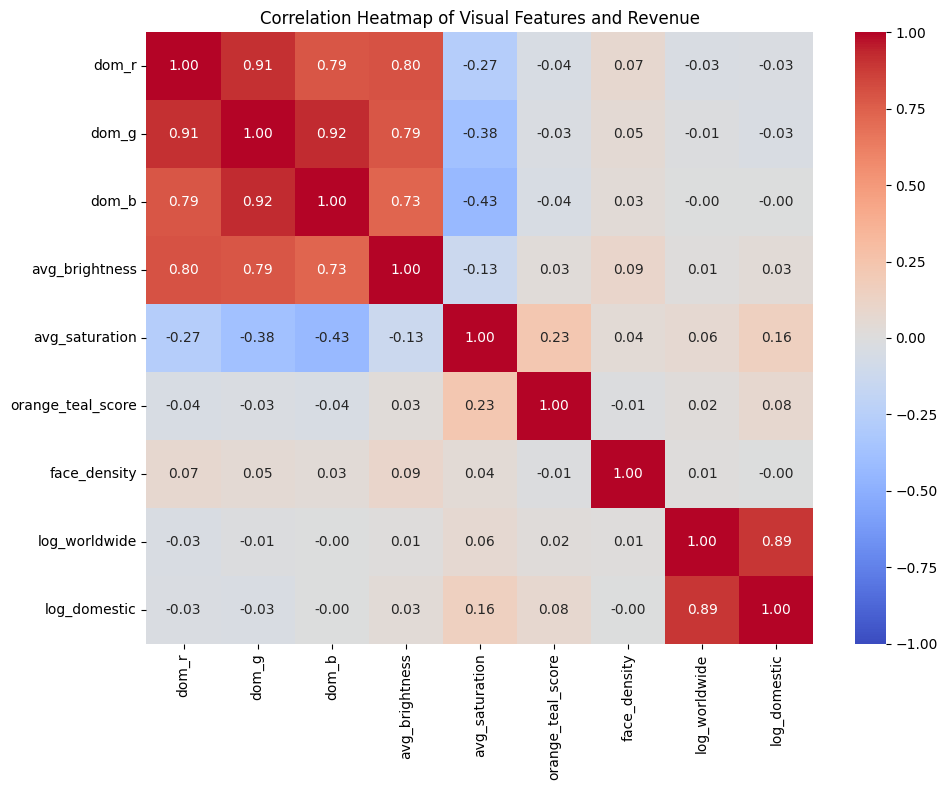

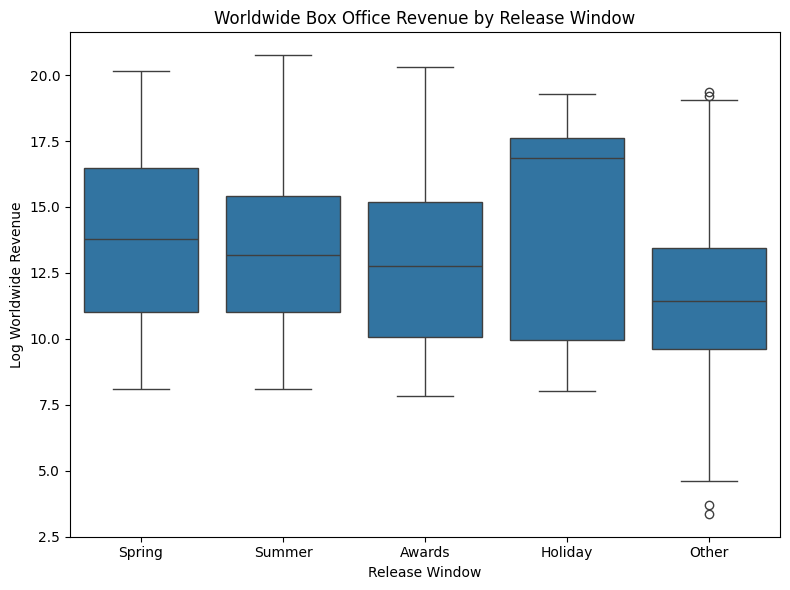

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the prepared dataset
# Ensure this matches the file name from your previous step
df = pd.read_csv("FEATURE_ENGINEERED_DATA.csv")

# 2. Correlation Heatmap
# Select only numerical features for the correlation matrix
numeric_cols = [
    'dom_r', 'dom_g', 'dom_b', 'avg_brightness', 'avg_saturation',
    'orange_teal_score', 'face_density', 'log_worldwide', 'log_domestic'
]

# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Visual Features and Revenue")
plt.tight_layout()
plt.show()

# 3. Bivariate Visualization: Revenue by Release Window
plt.figure(figsize=(8, 6))
sns.boxplot(x='release_window', y='log_worldwide', data=df, order=['Spring', 'Summer', 'Awards', 'Holiday', 'Other'])
plt.title("Worldwide Box Office Revenue by Release Window")
plt.xlabel("Release Window")
plt.ylabel("Log Worldwide Revenue")
plt.tight_layout()
plt.show()

# 4. Outlier Detection (Optional but recommended)
# Let's see that outlier with 44 faces
# print(df[df['face_count_retinaface'] == df['face_count_retinaface'].max()][['primaryTitle', 'face_count_retinaface', 'log_worldwide']])

In [9]:
import pandas as pd

# Load your prepared dataset
df = pd.read_csv("FEATURE_ENGINEERED_DATA.csv")

# Ensure the target variable has no NaNs to avoid calculation errors
df = df.dropna(subset=['log_worldwide'])

print("========== PART 1: CORRELATION HEATMAP STATISTICS ==========")
# Define the numeric columns used in your heatmap
numeric_cols = [
    'dom_r', 'dom_g', 'dom_b', 'avg_brightness', 'avg_saturation',
    'orange_teal_score', 'face_density', 'log_worldwide', 'log_domestic'
]

# Calculate the correlation matrix and isolate the target variable
corr_matrix = df[numeric_cols].corr()
target_corr = corr_matrix['log_worldwide'].sort_values(ascending=False)

print("\nExact Correlation Coefficients with 'log_worldwide':")
print(target_corr.to_string())


print("\n\n========== PART 2: BOXPLOT STATISTICS (BY RELEASE WINDOW) ==========")
# Calculate standard descriptive statistics (count, mean, std, min, 25%, 50%, 75%, max) 
# for worldwide revenue, grouped by the categorical release window.
window_stats = df.groupby('release_window')['log_worldwide'].describe()

# Sort by median (the 50% mark) to see which window performs best on average
window_stats_sorted = window_stats.sort_values(by='50%', ascending=False)

print("\nSummary Statistics for Log Worldwide Revenue by Release Window:")
print(window_stats_sorted.to_string())

========== PART 1: CORRELATION HEATMAP STATISTICS ==========

Exact Correlation Coefficients with 'log_worldwide':
log_worldwide        1.000000
log_domestic         0.892894
avg_saturation       0.064648
orange_teal_score    0.021503
avg_brightness       0.011828
face_density         0.010406
dom_b               -0.001049
dom_g               -0.014219
dom_r               -0.034021


========== PART 2: BOXPLOT STATISTICS (BY RELEASE WINDOW) ==========

Summary Statistics for Log Worldwide Revenue by Release Window:
                count       mean       std       min        25%        50%        75%        max
release_window                                                                                  
Holiday          15.0  14.406962  4.109123  8.015988   9.958087  16.848470  17.604750  19.299053
Spring           43.0  13.911493  3.418465  8.117014  11.003489  13.783684  16.487089  20.158781
Summer          106.0  13.552110  3.171216  8.103192  11.035537  13.183392  15.412418  20.7



### **Exploratory Data Analysis: Visual Features vs. Box Office Performance**

The initial exploratory phase aimed to identify linear relationships between the extracted visual features of movie posters and box office revenue, as well as to observe revenue trends across different theatrical release windows. A correlation matrix was generated to assess the linear association between continuous visual metrics and log-transformed worldwide revenue. The results indicated that the relationships between the visual features and worldwide revenue are universally weak. The strongest visual correlate is average saturation ($r = 0.065$), indicating a negligible positive relationship. Most notably, the variables central to the project's hypothesis—the orange/teal score ($r = 0.022$) and face density ($r = 0.010$) - show almost zero linear correlation with worldwide revenue. Furthermore, the individual RGB components of the most dominant color all exhibit slight negative correlations with revenue, which are too weak to be considered statistically or practically significant. This suggests that, in isolation, neither the presence of "Hollywood color grading" nor the density of actors on a poster is a strong linear predictor of global commercial success within this dataset.

A distributional analysis was then conducted to evaluate how worldwide revenue varies based on the categorized theatrical release window. The Holiday window (December) demonstrates the highest median ($16.85$) and mean ($14.41$) log worldwide revenue, though it also features the smallest sample size and largest variance. The Spring and Summer windows show comparable, strong performance, trailing the Holiday median but outperforming the Awards and "Other" windows. As expected, the Awards window (September–November) shows a lower median compared to the major blockbuster seasons, aligning with the tendency for these films to prioritize critical reception over peak commercial mass appeal. Ultimately, this preliminary analysis reveals that while theatrical release timing shows distinct distributional differences in box office revenue, the individual visual components of the posters lack meaningful linear correlations with revenue. The subsequent Multiple Linear Regression will be necessary to determine if these visual features gain predictive power when controlling for the release window, or if interaction effects exist.

Part 2: Categorical Encoding and Feature Scaling

This step prepares the data for modeling. Machine learning algorithms need numbers, not text. We will use pd.get_dummies to one-hot encode the categorical variables (release_window and genres) and StandardScaler from scikit-learn to normalize our continuous features.

In [4]:
from sklearn.preprocessing import StandardScaler

# 1. Handle Missing Values
# Ensure the target variable has no NaNs
df = df.dropna(subset=['log_worldwide'])

# 2. One-Hot Encoding for 'release_window'
# drop_first=True prevents the dummy variable trap (perfect multicollinearity)
df_encoded = pd.get_dummies(df, columns=['release_window'], drop_first=True)

# Note: If you plan to use 'genres', you would encode them here as well.
# Since genres are pipe-separated (e.g., 'Action|Comedy'), it's more complex.
# For simplicity, we'll focus on release_window and the visual features for now.

# 3. Define Predictors (X) and Target (y)
# Let's include the new dummy variables and the visual features
features_to_scale = ['avg_brightness', 'avg_saturation', 'orange_teal_score', 'face_density']

# Identify the dummy columns created
window_dummies = [col for col in df_encoded.columns if col.startswith('release_window_')]

# Combine visual features and dummies for X
X_cols = features_to_scale + window_dummies
X = df_encoded[X_cols]
y = df_encoded['log_worldwide']

# 4. Feature Scaling (Standardization)
scaler = StandardScaler()
# We only scale the continuous numerical features, not the binary dummy variables
X_scaled = X.copy()
X_scaled[features_to_scale] = scaler.fit_transform(X[features_to_scale])

# Display the prepared feature set
print(X_scaled.head())

   avg_brightness  avg_saturation  orange_teal_score  face_density  \
0        1.399291        0.019252           1.066177      0.015943   
1       -1.469112       -0.930234          -0.197084     -0.264502   
2        1.794584       -1.571686          -0.588203      1.415181   
3       -1.278942       -0.132259          -0.691854      1.418169   
4       -0.523916        0.921563          -0.849190     -0.544947   

   release_window_Holiday  release_window_Other  release_window_Spring  \
0                   False                  True                  False   
1                   False                  True                  False   
2                   False                  True                  False   
3                   False                  True                  False   
4                   False                  True                  False   

   release_window_Summer  
0                  False  
1                  False  
2                  False  
3                  False  



**Data Transformation Overview**
This output confirms that oour data preprocessing was executed correctly. The continuous variables have been transformed into **Z-scores** (standardized), and the categorical `release_window` has been successfully **one-hot encoded**.

**1. Interpreting the Scaled Visual Features**
Because these are Z-scores, a value of `0` represents the dataset average, positive values are above average, and negative values are below average (measured in standard deviations):
* **Row 0** represents a poster that is significantly brighter than average (`1.39`) and features a highly prominent "Hollywood" orange/teal color grading (`1.06`).
* **Row 1** represents a very dark (`-1.46`) and desaturated (`-0.93`) poster with below-average face density.
* **Rows 2 and 3** represent posters with exceptionally high face densities (`1.41` and `1.42`), meaning they likely feature ensemble casts or prominent "floating head" designs.

**2. Interpreting the Categorical Features**
The `release_window` variables have been expanded into binary (True/False) columns. For all five of these initial rows, `release_window_Other` is **True**, while Holiday, Spring, and Summer are **False**. This indicates that these specific films were released outside of your primary named seasonal windows (e.g., they were likely released in January or February). Note that the "Awards" window is not shown here; as the dropped reference category, a film would be classed as an "Awards" release if all visible window columns were False.

This standardized format ensures that no single visual feature (like brightness, which originally ranged from 0-255) will overpower our regression model simply because it has larger raw numbers than your face density or orange/teal scores.

Part 3: Statistical Inference (Multiple Linear Regression)

This chunk uses the statsmodels library. It's the best tool in Python for getting detailed statistical summaries, including the p-values we need to answer the research question about statistical significance.

In [6]:
import statsmodels.api as sm

# 1. THE FIX: Force all data to be float numbers (converts True/False to 1.0/0.0)
X_scaled = X_scaled.astype(float)
y = y.astype(float)

# 2. Add a Constant
# statsmodels requires manually adding a constant for the intercept
X_with_const = sm.add_constant(X_scaled)

# 3. Fit the Model
# OLS stands for Ordinary Least Squares regression
model = sm.OLS(y, X_with_const).fit()

# 4. Print the Statistical Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_worldwide   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     11.73
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.75e-16
Time:                        11:18:13   Log-Likelihood:                -2465.8
No. Observations:                1000   AIC:                             4950.
Df Residuals:                     991   BIC:                             4994.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     12



### **Statistical Inference: Multiple Linear Regression Results**

A Multiple Linear Regression was conducted to determine the effect of visual poster features and theatrical release windows on log-transformed worldwide box office revenue. 

**1. Overall Model Fit**
The regression model is statistically significant overall ($F(8, 991) = 11.73$, $p < 0.001$), meaning the combined predictors predict the outcome variable better than a null model. However, the model possesses very weak explanatory power. The R-squared value of $0.087$ indicates that the chosen visual features and release windows collectively account for only 8.7% of the variance in worldwide box office revenue. This suggests that the vast majority of commercial success is driven by external factors not captured in this model (e.g., marketing budget, IP recognition, critical reception).

**2. Evaluation of Core Hypotheses (Visual Features)**
The regression results fail to support the project's primary hypotheses. Controlling for release timing, neither the **Orange/Teal Score** ($p = 0.724$) nor **Face Density** ($p = 0.369$) reach the threshold for statistical significance ($\alpha = 0.05$). This demonstrates that the presence of high-contrast Hollywood color grading and the density of human faces on a poster do not reliably predict higher box office returns within this dataset. 

Among the visual predictors, only **Average Saturation** demonstrates a statistically significant positive relationship with worldwide revenue ($p = 0.027$). The positive coefficient ($\beta = 0.208$) suggests that more vividly colored posters are weakly but significantly associated with higher global financial performance, holding all other variables constant.

**3. Release Window Analysis**
In this model, the "Awards" window serves as the baseline reference category (as it is the omitted dummy variable). The only statistically significant temporal predictor is the **"Other"** category ($p < 0.001$). The strong negative coefficient ($\beta = -1.432$) indicates that films released outside of the major recognized seasonal windows (Summer, Holiday, Spring, Awards) perform significantly worse at the global box office compared to Awards season releases. While the Holiday and Spring windows show positive coefficients, their $p$-values ($0.088$ and $0.092$, respectively) indicate that they are not statistically distinct from the Awards baseline at the strict 0.05 significance level within this multivariate context.

Part 4: Interaction Hypothesis

This step directly addresses the second part of your research question: do visual trends vary by release window? We create new variables by multiplying the visual feature scores by the release window dummy variables.

In [7]:
# 1. Create Interaction Terms
# We want to multiply 'orange_teal_score' by each release window dummy
for window_col in window_dummies:
    interaction_col_name = f"interaction_OT_x_{window_col.replace('release_window_', '')}"
    # Multiplying scaled feature by binary 0 or 1
    X_scaled[interaction_col_name] = X_scaled['orange_teal_score'] * X_scaled[window_col]

# 2. Fit the New Model with Interactions
X_interaction_with_const = sm.add_constant(X_scaled)
interaction_model = sm.OLS(y, X_interaction_with_const).fit()

# 3. Print the Summary
print("--- Model with Interaction Terms ---")
print(interaction_model.summary())

# Check the p-values of the new 'interaction_...' variables.
# If significant, it means the effect of Orange/Teal is different in that specific window!

--- Model with Interaction Terms ---
                            OLS Regression Results                            
Dep. Variable:          log_worldwide   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     7.823
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.67e-14
Time:                        11:18:48   Log-Likelihood:                -2465.6
No. Observations:                1000   AIC:                             4957.
Df Residuals:                     987   BIC:                             5021.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


### **Statistical Inference: Interaction Effects Analysis**

An expanded Multiple Linear Regression was conducted to test for interaction effects—specifically, whether the financial impact of the "Orange/Teal" color grading strategy changes depending on the theatrical release window. 

**1. Model Fit and Explanatory Power**
The inclusion of interaction terms did not improve the overall predictive power of the model. While the overall model remains statistically significant ($p < 0.001$), the R-squared value remained stagnant at $0.087$, and the Adjusted R-squared slightly decreased from $0.079$ to $0.076$. This mathematical penalty indicates that adding the interaction variables introduced unnecessary complexity without explaining any additional variance in global box office revenue.

**2. Evaluation of Interaction Terms**
The results fail to support the hypothesis that visual trends perform differently across specific theatrical windows. 
* **Baseline Effect:** The main effect for `orange_teal_score` ($p = 0.997$) represents the impact of this color grading specifically within the baseline "Awards" season. The near-perfect $1.0$ $p$-value indicates that orange/teal grading has absolutely no measurable linear relationship with revenue for Awards season films.
* **Holiday Interaction:** The interaction term `interaction_OT_x_Holiday` ($p = 0.767$) tests whether the effect of orange/teal grading is statistically different in the Holiday window compared to the Awards baseline. Because this $p$-value is well above the $0.05$ threshold, there is no evidence to suggest that highly saturated orange and teal posters yield better financial returns during the Holiday season than they do during the rest of the year. (This pattern holds true for the remaining interaction terms).

**3. Consistency of Main Effects**
Controlling for these interactions did not alter the core findings from the initial model. **Average Saturation** remains the sole statistically significant visual predictor ($p = 0.027$, $\beta = 0.210$), indicating that overall color vividness is weakly associated with higher revenue regardless of the season. Similarly, the **"Other"** release window remains a highly significant negative predictor ($p < 0.001$), confirming that films released outside of major theatrical seasons consistently underperform at the global box office compared to the baseline.

**Conclusion on Visual Strategy:**
The data suggests that while broad seasonal release strategies heavily impact financial outcomes, the effectiveness of specific visual marketing tactics (like high-contrast color palettes or face density) remains flat across the calendar year. A poster's color grading does not appear to require seasonal tailoring to maximize box office returns.

Part 5: Predictive Modeling & Evaluation

This final chunk shifts from statistical explanation to pure prediction. We split the data 80/20, train a RandomForestRegressor, and evaluate its performance using metrics like Mean Absolute Error (MAE) and R-squared. We also extract feature importances to see which visual element the model relied on the most.

--- Random Forest Performance ---
Mean Absolute Error (MAE): 2.5859
Root Mean Squared Error (RMSE): 3.0870
R-squared (R2): -0.1203


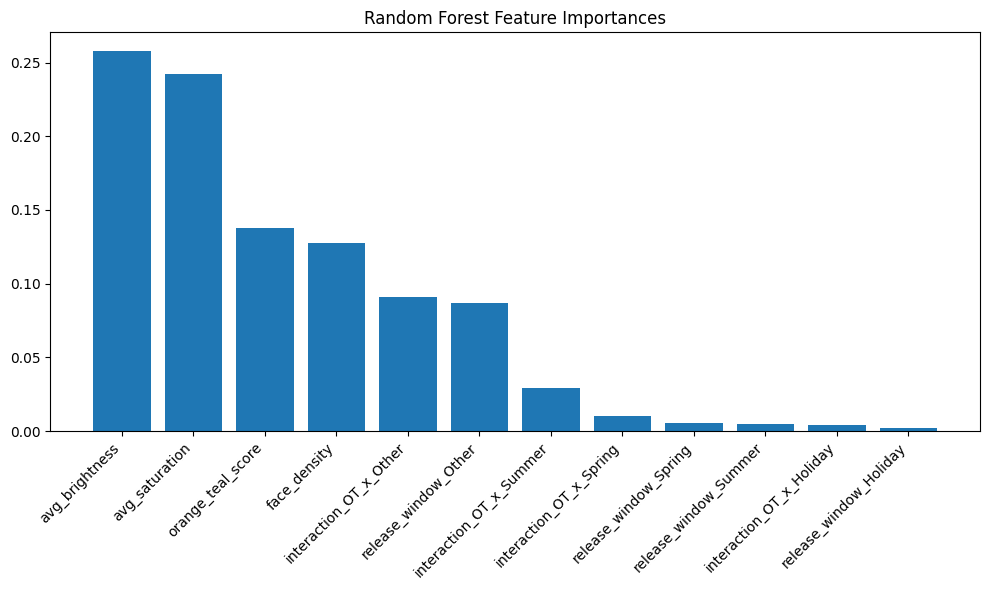

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Train/Test Split (80/20)
# Use the X_scaled (without the statsmodels constant)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Initialize and Train the Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Make Predictions on the Test Set
y_pred = rf_model.predict(X_test)

# 4. Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Random Forest Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# 5. Feature Importance Visualization
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

print("========== PART 5: PREDICTIVE MODELING STATISTICS ==========")
# 1. Print the exact evaluation metrics
print("Model Performance Metrics:")
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Root Mean Sq Error (RMSE) : {rmse:.4f}")
print(f"R-squared (R2)            : {r2:.4f}\n")

# 2. Extract and format the feature importances
print("Feature Importances (Ranked):")
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Weight': rf_model.feature_importances_
}).sort_values(by='Importance Weight', ascending=False)

# Format as a percentage for easier reading
importance_df['Importance (%)'] = (importance_df['Importance Weight'] * 100).round(2)

print(importance_df[['Feature', 'Importance (%)']].to_string(index=False))

========== PART 5: PREDICTIVE MODELING STATISTICS ==========
Model Performance Metrics:
Mean Absolute Error (MAE) : 2.5859
Root Mean Sq Error (RMSE) : 3.0870
R-squared (R2)            : -0.1203

Feature Importances (Ranked):
                 Feature  Importance (%)
          avg_brightness           25.76
          avg_saturation           24.21
       orange_teal_score           13.80
            face_density           12.74
  interaction_OT_x_Other            9.13
    release_window_Other            8.72
 interaction_OT_x_Summer            2.94
 interaction_OT_x_Spring            1.02
   release_window_Spring            0.56
   release_window_Summer            0.51
interaction_OT_x_Holiday            0.39
  release_window_Holiday            0.23


Predictive Modeling: Random Forest Evaluation

A Random Forest regressor was trained to evaluate whether the combination of visual poster features and temporal release data could accurately predict the log-transformed worldwide box office revenue of a film. The results indicate that the current feature set does not possess predictive validity.

1. Model Performance and Generalization
The evaluation metrics on the testing data demonstrate a severe lack of predictive power. Most notably, the model yielded a negative R-squared value (-0.1203). An R-squared below zero indicates that the Random Forest model performs worse on unseen data than a naive baseline model that simply predicts the mean revenue of the training set for every film. Furthermore, the Mean Absolute Error (MAE) of 2.5859 and Root Mean Squared Error (RMSE) of 3.0870 are exceptionally high given that the target variable is log-transformed. An error of over 2.5 log units translates to predictions being off by massive multiples in actual dollar amounts. This confirms that the model entirely failed to generalize.

2. Feature Importance Analysis
Although the model lacks predictive validity on the test set, analyzing the feature importances reveals which variables the algorithm relied upon most heavily to make its structural splits during training.

General Aesthetics over Specific Strategies: The model assigned the highest importance weights to Average Brightness (25.76%) and Average Saturation (24.21%). These broad, fundamental image properties accounted for roughly half of the model's decision-making weight.

Hypothesis Features: The core features hypothesized to drive revenue—Orange/Teal Score (13.80%) and Face Density (12.74%)—served as secondary decision nodes, collectively accounting for just over a quarter of the model's internal weighting.

Temporal Variables: Unlike the linear regression model where the "Other" release window was highly significant, the Random Forest assigned very little weight to the categorical release windows and their interaction terms (all scoring under 10%, with most under 1%). Tree-based models often struggle to utilize sparse, one-hot encoded categorical data effectively compared to continuous variables.

Conclusion
The predictive modeling phase strongly corroborates the findings from the statistical inference phase. The visual elements of a movie poster—whether measuring basic luminance or highly specific Hollywood color-grading trends—do not contain enough mathematical signal to predict global box office returns. The failure of a complex, non-linear model to capture any predictive pattern suggests that commercial success is overwhelmingly dictated by external factors excluded from this dataset, such as marketing budgets, franchise intellectual property, and established star power.

We now redo the entire analysis but now on ALL of the film posters.

In [14]:
import pandas as pd
import requests
import os
import time
from tqdm import tqdm

# --- Configuration ---
API_KEY = "40b746fe3d756e4c2d54323e530a5911"
INPUT_FILE = "FILTERED_RELEASE_SCHEDULE.csv"
SAVE_DIR = "all_posters"
BASE_IMAGE_URL = "https://image.tmdb.org/t/p/w500"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# 1. Load and Filter Dataset
df = pd.read_csv(INPUT_FILE)

# Keep rows where at least one financial column is not null
financial_cols = ['domestic', 'worldwide', 'international']
df_filtered = df[df[financial_cols].notna().any(axis=1)].copy()

# 2. Take a Random Sample of 20000
# If the dataset has fewer than 100 rows, it will take all of them
sample_size = min(21796, len(df_filtered))
df_sample = df_filtered.sample(n=sample_size, random_state=42)

print(f"Filtered dataset from {len(df)} to {len(df_filtered)} films with financial data.")
print(f"Proceeding with a random sample of {sample_size} films.")

def get_poster_by_imdb_id(tconst):
    """Uses TMDb Find endpoint to get movie poster via IMDb ID."""
    # The 'find' endpoint is perfect for tconst lookups
    url = f"https://api.themoviedb.org/3/find/{tconst}"
    params = {
        "api_key": API_KEY,
        "external_source": "imdb_id"
    }
    
    try:
        response = requests.get(url, params=params).json()
        # Find results are grouped by type (movie_results, tv_results, etc.)
        movie_results = response.get('movie_results', [])
        
        if movie_results:
            path = movie_results[0].get('poster_path')
            if path:
                return f"{BASE_IMAGE_URL}{path}"
    except Exception as e:
        print(f"Error finding ID {tconst}: {e}")
    return None

# 3. Download Loop
results = []

for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    tconst = row['tconst']
    title = row['primaryTitle']
    
    poster_url = get_poster_by_imdb_id(tconst)
    
    if poster_url:
        # Save filename using tconst to ensure it's unique and valid
        filename = f"{tconst}.jpg"
        save_path = os.path.join(SAVE_DIR, filename)
        
        try:
            img_data = requests.get(poster_url).content
            with open(save_path, 'wb') as f:
                f.write(img_data)
            
            # Record success
            row_data = row.to_dict()
            row_data['local_poster_path'] = save_path
            results.append(row_data)
        except Exception as e:
            print(f"Failed to download {title}: {e}")
    
    # Respect rate limits
    time.sleep(0.1)

# 4. Save the Final Mapping
final_df = pd.DataFrame(results)
final_df.to_csv("SAMPLED_POSTER_METADATA.csv", index=False)
print(f"\nSuccess! {len(final_df)} posters downloaded.")

/var/folders/bc/crsg43752y91kmjz_f8rjgnw0000gn/T/ipykernel_54824/3401175873.py:17: DtypeWarning: Columns (230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_FILE)


Filtered dataset from 21795 to 21795 films with financial data.
Proceeding with a random sample of 21795 films.


 12%|█▏        | 2611/21795 [19:12<1:52:27,  2.84it/s]

Error finding ID tt8879666: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))


100%|██████████| 21795/21795 [2:42:22<00:00,  2.24it/s]  



Success! 21753 posters downloaded.


Getting Metadata for all of the posters

In [ ]:
import cv2
import pandas as pd
import numpy as np
import os
from sklearn.cluster import KMeans
from tqdm import tqdm

# --- Configuration ---
IMAGE_DIR = "all_posters"
METADATA_FILE = "SAMPLED_POSTER_METADATA.csv"
CLUSTERS = 5 # Number of dominant colors to find per poster

# Load the metadata we created in the last step
df = pd.read_csv(METADATA_FILE)

def get_dominant_colors(image_path, k=5):
    """Loads an image and returns the k-dominant RGB colors."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # 1. Convert BGR (OpenCV default) to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Resize to speed up processing (200px width is enough for color analysis)
    height, width, _ = img.shape
    new_width = 200
    new_height = int(height * (new_width / width))
    img = cv2.resize(img, (new_width, new_height), interpolation=cv2.INTER_AREA)
    
    # 3. Reshape the image to be a list of pixels
    pixels = img.reshape((-1, 3))
    
    # 4. Cluster pixels using KMeans
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=42)
    kmeans.fit(pixels)
    
    # Get colors (cluster centers) and convert to integer
    colors = kmeans.cluster_centers_.astype(int)
    
    # Sort colors by how frequently they appear (optional but helpful)
    labels = list(kmeans.labels_)
    counts = [labels.count(i) for i in range(k)]
    sorted_colors = [colors[i] for i in np.argsort(counts)[::-1]]
    
    return sorted_colors

# --- Processing Loop ---
print(f"Analyzing color palettes for {len(df)} posters...")
palette_data = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row['local_poster_path']
    
    if os.path.exists(path):
        palette = get_dominant_colors(path, k=CLUSTERS)
        # Store as a list of RGB tuples
        palette_data.append(palette)
    else:
        palette_data.append(None)

# Add the new column and save
df['color_palette_rgb'] = palette_data
df.to_csv("FINAL_ANALYSIS_READY_DATA_v2.csv", index=False)
print("Analysis complete! Palettes saved to 'FINAL_ANALYSIS_READY_DATA.csv'")

FileNotFoundError: [Errno 2] No such file or directory: 'SAMPLED_POSTER_METADATA_ALL.csv'

Applying RetinaFace to the complete dataset

In [ ]:
import os

# MUST be set before any TensorFlow/Keras import.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

os.chdir("/Users/rowanrosenblum/PycharmProjects/JupyterProject")
print(f"Working directory: {os.getcwd()}")

from retinaface import RetinaFace
import pandas as pd
from tqdm import tqdm

# --- Configuration ---
INPUT_FILE  = "FINAL_ANALYSIS_READY_DATA_2.csv"
OUTPUT_FILE = "COMPLETE_ANALYSIS_DATA_ALL.csv"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Could not find {INPUT_FILE}.")

df = pd.read_csv(INPUT_FILE)

# Sample 50 movies for testing
df = df.sample(n=1000, random_state=42).reset_index(drop=True)
print(f"Running on a sample of {len(df)} posters...")

def count_faces_retinaface(image_path):
    try:
        faces = RetinaFace.detect_faces(image_path)
        if isinstance(faces, dict):
            return len(faces)
        return 0
    except Exception as e:
        print(f"Error on {image_path}: {e}")
        return 0

face_counts = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row["local_poster_path"]
    face_counts.append(
        count_faces_retinaface(path)
        if isinstance(path, str) and os.path.exists(path)
        else 0
    )

df["face_count_retinaface"] = face_counts
df.to_csv(OUTPUT_FILE, index=False)

print(f"\nSuccess! Saved to '{OUTPUT_FILE}'.")
print(f"Faces detected — median: {pd.Series(face_counts).median()}, max: {pd.Series(face_counts).max()}")
print(df[["primaryTitle", "face_count_retinaface", "worldwide"]].head(10).to_string(index=False))


Getting more data for all of the posters

In [1]:
import os
import re
import ast
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm

os.chdir("/Users/rowanrosenblum/PycharmProjects/JupyterProject")

INPUT_FILE  = "COMPLETE_ANALYSIS_DATA_ALL.csv"
OUTPUT_FILE = "FEATURE_ENGINEERED_DATA_ALL.csv"

df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows from {INPUT_FILE}")

# ── 1. Parse dominant color from color_palette_rgb ──────────────────────────
# Stored as "[array([r, g, b]), ...]" — use regex to extract all integers
def parse_dominant_color(palette_str):
    """Extracts RGB of the most dominant (first) color using regex."""
    try:
        # Find all groups of 3 integers (each array([r, g, b]))
        groups = re.findall(r'array\(\[\s*(\d+),\s*(\d+),\s*(\d+)\s*\]\)', str(palette_str))
        if groups:
            r, g, b = groups[0]
            return int(r), int(g), int(b)
    except Exception:
        pass
    return None, None, None

dom = df["color_palette_rgb"].apply(parse_dominant_color)
df["dom_r"] = [x[0] for x in dom]
df["dom_g"] = [x[1] for x in dom]
df["dom_b"] = [x[2] for x in dom]

# ── 2. Per-image: brightness, saturation, orange-teal score ─────────────────
def extract_image_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).reshape(-1, 3)
    h, s, v = hsv[:, 0], hsv[:, 1], hsv[:, 2]
    avg_brightness    = float(np.mean(v))
    avg_saturation    = float(np.mean(s))
    orange_mask       = (h >= 3)  & (h <= 13)   # ~5-25 deg
    teal_mask         = (h >= 85) & (h <= 100)  # ~170-200 deg
    orange_teal_score = float(np.mean(orange_mask | teal_mask))
    return avg_brightness, avg_saturation, orange_teal_score

print("Extracting per-image color features...")
brightness_list, saturation_list, ot_score_list = [], [], []
for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row["local_poster_path"]
    if isinstance(path, str) and os.path.exists(path):
        b, s, ot = extract_image_features(path)
    else:
        b, s, ot = None, None, None
    brightness_list.append(b)
    saturation_list.append(s)
    ot_score_list.append(ot)

df["avg_brightness"]    = brightness_list
df["avg_saturation"]    = saturation_list
df["orange_teal_score"] = ot_score_list

# ── 3. Face density (faces per 10,000 pixels) ───────────────────────────────
def get_image_area(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    h, w, _ = img.shape
    return h * w

print("Computing face density...")
areas = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    path = row["local_poster_path"]
    areas.append(get_image_area(path) if isinstance(path, str) and os.path.exists(path) else None)

df["image_area"]   = areas
df["face_density"] = df["face_count_retinaface"] / (df["image_area"] / 10_000)

# ── 4. Log-transformed revenue (strip $, commas first) ───────────────────────
def clean_currency(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r'[\$,]', '', regex=True),
        errors="coerce"
    )

df["log_worldwide"] = np.log1p(clean_currency(df["worldwide"]))
df["log_domestic"]  = np.log1p(clean_currency(df["domestic"]))

# ── 5. Release window ────────────────────────────────────────────────────────
def classify_release_window(date_str):
    try:
        month = pd.to_datetime(date_str).month
        if month in [5, 6, 7, 8]:  return "Summer"
        if month in [9, 10, 11]:   return "Awards"
        if month == 12:            return "Holiday"
        if month in [3, 4]:        return "Spring"
        return "Other"
    except Exception:
        return None

df["release_window"] = df["first_us_theatrical_date"].apply(classify_release_window)

# ── 6. Save ──────────────────────────────────────────────────────────────────
df.to_csv(OUTPUT_FILE, index=False)
print(f"\nSaved to '{OUTPUT_FILE}' with {len(df)} rows.")

new_cols = ["dom_r", "dom_g", "dom_b", "avg_brightness", "avg_saturation",
            "orange_teal_score", "face_density", "log_worldwide", "log_domestic", "release_window"]
print(df[new_cols].describe(include="all").round(3))


/var/folders/bc/crsg43752y91kmjz_f8rjgnw0000gn/T/ipykernel_80427/2357650211.py:14: DtypeWarning: Columns (299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_FILE)


Loaded 21753 rows from COMPLETE_ANALYSIS_DATA_ALL.csv
Extracting per-image color features...


100%|██████████| 21753/21753 [02:09<00:00, 167.76it/s]


Computing face density...


100%|██████████| 21753/21753 [01:20<00:00, 271.25it/s]



Saved to 'FEATURE_ENGINEERED_DATA_ALL.csv' with 21753 rows.
            dom_r      dom_g      dom_b  avg_brightness  avg_saturation  \
count   21753.000  21753.000  21753.000       21753.000       21753.000   
unique        NaN        NaN        NaN             NaN             NaN   
top           NaN        NaN        NaN             NaN             NaN   
freq          NaN        NaN        NaN             NaN             NaN   
mean      102.571     96.019     92.295         132.782         106.893   
std        93.750     90.223     87.852          50.554          48.078   
min         0.000      0.000      0.000           0.000           0.000   
25%        19.000     18.000     19.000          93.100          71.983   
50%        53.000     48.000     47.000         135.245         105.311   
75%       211.000    192.000    184.000         172.721         139.924   
max       254.000    254.000    254.000         251.135         250.900   

        orange_teal_score  face_densit

Doing EDA for all posters

/var/folders/bc/crsg43752y91kmjz_f8rjgnw0000gn/T/ipykernel_80427/3874469675.py:7: DtypeWarning: Columns (299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("FEATURE_ENGINEERED_DATA_ALL.csv")


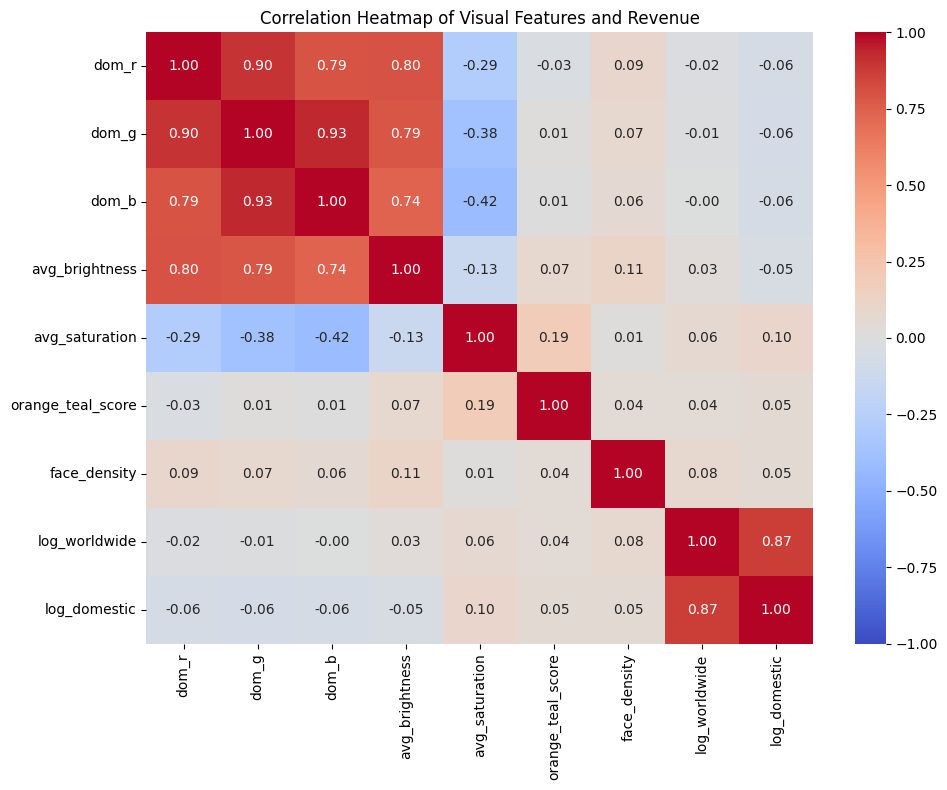

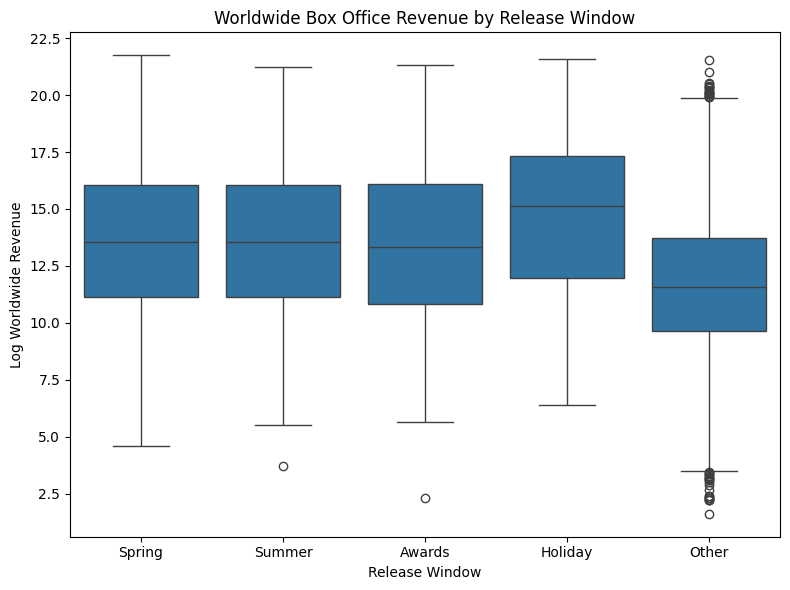

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the prepared dataset
# Ensure this matches the file name from your previous step
df = pd.read_csv("FEATURE_ENGINEERED_DATA_ALL.csv")

# 2. Correlation Heatmap
# Select only numerical features for the correlation matrix
numeric_cols = [
    'dom_r', 'dom_g', 'dom_b', 'avg_brightness', 'avg_saturation',
    'orange_teal_score', 'face_density', 'log_worldwide', 'log_domestic'
]

# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Visual Features and Revenue")
plt.tight_layout()
plt.show()

# 3. Bivariate Visualization: Revenue by Release Window
plt.figure(figsize=(8, 6))
sns.boxplot(x='release_window', y='log_worldwide', data=df, order=['Spring', 'Summer', 'Awards', 'Holiday', 'Other'])
plt.title("Worldwide Box Office Revenue by Release Window")
plt.xlabel("Release Window")
plt.ylabel("Log Worldwide Revenue")
plt.tight_layout()
plt.show()

# 4. Outlier Detection (Optional but recommended)
# Let's see that outlier with 44 faces
# print(df[df['face_count_retinaface'] == df['face_count_retinaface'].max()][['primaryTitle', 'face_count_retinaface', 'log_worldwide']])

Getting the statistics behind these visuals

In [3]:
import pandas as pd

# Load your prepared dataset
df = pd.read_csv("FEATURE_ENGINEERED_DATA_ALL.csv")

# Ensure the target variable has no NaNs to avoid calculation errors
df = df.dropna(subset=['log_worldwide'])

print("========== PART 1: CORRELATION HEATMAP STATISTICS ==========")
# Define the numeric columns used in your heatmap
numeric_cols = [
    'dom_r', 'dom_g', 'dom_b', 'avg_brightness', 'avg_saturation',
    'orange_teal_score', 'face_density', 'log_worldwide', 'log_domestic'
]

# Calculate the correlation matrix and isolate the target variable
corr_matrix = df[numeric_cols].corr()
target_corr = corr_matrix['log_worldwide'].sort_values(ascending=False)

print("\nExact Correlation Coefficients with 'log_worldwide':")
print(target_corr.to_string())


print("\n\n========== PART 2: BOXPLOT STATISTICS (BY RELEASE WINDOW) ==========")
# Calculate standard descriptive statistics (count, mean, std, min, 25%, 50%, 75%, max) 
# for worldwide revenue, grouped by the categorical release window.
window_stats = df.groupby('release_window')['log_worldwide'].describe()

# Sort by median (the 50% mark) to see which window performs best on average
window_stats_sorted = window_stats.sort_values(by='50%', ascending=False)

print("\nSummary Statistics for Log Worldwide Revenue by Release Window:")
print(window_stats_sorted.to_string())

/var/folders/bc/crsg43752y91kmjz_f8rjgnw0000gn/T/ipykernel_80427/3721452746.py:4: DtypeWarning: Columns (299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("FEATURE_ENGINEERED_DATA_ALL.csv")


========== PART 1: CORRELATION HEATMAP STATISTICS ==========

Exact Correlation Coefficients with 'log_worldwide':
log_worldwide        1.000000
log_domestic         0.869033
face_density         0.077885
avg_saturation       0.064068
orange_teal_score    0.041867
avg_brightness       0.028721
dom_b               -0.004635
dom_g               -0.013172
dom_r               -0.018423


========== PART 2: BOXPLOT STATISTICS (BY RELEASE WINDOW) ==========

Summary Statistics for Log Worldwide Revenue by Release Window:
                  count       mean       std       min        25%        50%        75%        max
release_window                                                                                    
Holiday           439.0  14.555180  3.436424  6.401917  11.975404  15.115841  17.323036  21.571057
Spring            981.0  13.653487  3.169041  4.605170  11.140179  13.552411  16.046194  21.752685
Summer           1796.0  13.730789  3.275025  3.688879  11.134828  13.547294  16.07

1. Visual Features Have Very Weak Linear Correlation with Box office
The correlation matrix (Part 1) shows how different features relate to a film's worldwide revenue (log-transformed).

Strongest Predictor (Non-Visual): As expected, Domestic Revenue (log_domestic) is highly correlated with Worldwide Revenue ($r \approx 0.87$).
Face Density: Out of all visual features, the density of faces on the poster (face_density) has the highest positive correlation with revenue, though it is still very weak ($r \approx 0.078$). This suggests that posters with more or larger faces (often implying an ensemble cast or star power) have a very slight positive association with higher revenues.
Color and Aesthetics: Features like saturation ($r \approx 0.064$), the "Orange-Teal" aesthetic score ($r \approx 0.042$), and average brightness ($r \approx 0.029$) show close to zero correlation.
Dominant Colors: The dominant RGB values (dom_r, dom_g, dom_b) have basically zero correlation with financial success (meaning you cannot predict revenue based linearly on how red, green, or blue the poster is).
2. Release Window is a Strong Indicator of Performance
The summary statistics (Part 2) reveal a clear hierarchy of financial performance based on when a movie is released:

The Holiday Premium: Films released during the Holiday window perform best by a significant margin. They have the highest median revenue (15.11 log scale) and the highest average revenue (14.55 log scale). It is also the most exclusive window (only 439 films).
Spring & Summer are Highly Competitive: Spring and Summer perform very similarly. Spring has a slightly higher median (13.55 vs 13.54), but Summer has a slightly higher mean (13.73 vs 13.65). Summer is the most crowded of the major release windows (1,796 films).
Awards Season: Surprisingly, the Awards window performs slightly behind Spring and Summer, with a median of 13.34.
The "Other" Penalty: Films released outside these major windows ("Other") perform significantly worse, with a median of 11.58. They represent the vast majority of the dataset (16,918 films), suggesting this window captures a multitude of lower-budget, independent, or direct-to-video films.

Categorical encoding and feature scaling

In [4]:
from sklearn.preprocessing import StandardScaler

# 1. Handle Missing Values
# Ensure the target variable has no NaNs
df = df.dropna(subset=['log_worldwide'])

# 2. One-Hot Encoding for 'release_window'
# drop_first=True prevents the dummy variable trap (perfect multicollinearity)
df_encoded = pd.get_dummies(df, columns=['release_window'], drop_first=True)

# Note: If you plan to use 'genres', you would encode them here as well.
# Since genres are pipe-separated (e.g., 'Action|Comedy'), it's more complex.
# For simplicity, we'll focus on release_window and the visual features for now.

# 3. Define Predictors (X) and Target (y)
# Let's include the new dummy variables and the visual features
features_to_scale = ['avg_brightness', 'avg_saturation', 'orange_teal_score', 'face_density']

# Identify the dummy columns created
window_dummies = [col for col in df_encoded.columns if col.startswith('release_window_')]

# Combine visual features and dummies for X
X_cols = features_to_scale + window_dummies
X = df_encoded[X_cols]
y = df_encoded['log_worldwide']

# 4. Feature Scaling (Standardization)
scaler = StandardScaler()
# We only scale the continuous numerical features, not the binary dummy variables
X_scaled = X.copy()
X_scaled[features_to_scale] = scaler.fit_transform(X[features_to_scale])

# Display the prepared feature set
print(X_scaled.head())

   avg_brightness  avg_saturation  orange_teal_score  face_density  \
0       -1.277417        0.429131          -0.367115      1.625632   
1        1.025364       -0.291530          -0.497457     -0.796839   
2        0.483293        2.256438           0.645205     -0.539518   
3        0.075771        0.839205          -0.699515     -0.796839   
4       -0.390018        0.033587           0.356962      1.261723   

   release_window_Holiday  release_window_Other  release_window_Spring  \
0                   False                  True                  False   
1                   False                 False                  False   
2                   False                 False                  False   
3                   False                  True                  False   
4                   False                  True                  False   

   release_window_Summer  
0                  False  
1                   True  
2                   True  
3                  False  

Multiple linear regression

In [5]:
import statsmodels.api as sm

# 1. THE FIX: Force all data to be float numbers (converts True/False to 1.0/0.0)
X_scaled = X_scaled.astype(float)
y = y.astype(float)

# 2. Add a Constant
# statsmodels requires manually adding a constant for the intercept
X_with_const = sm.add_constant(X_scaled)

# 3. Fit the Model
# OLS stands for Ordinary Least Squares regression
model = sm.OLS(y, X_with_const).fit()

# 4. Print the Statistical Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_worldwide   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     287.6
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:32:10   Log-Likelihood:                -53996.
No. Observations:               21753   AIC:                         1.080e+05
Df Residuals:                   21744   BIC:                         1.081e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     13

1. Overall Model Performance
R-squared (0.096): This model explains about 9.6% of the variance in worldwide box office revenue. While this seems low, it is actually quite typical when trying to predict something as unpredictable as box office performance using only high-level visual features and release timing.
F-Statistic (Prob: 0.00): The model as a whole is highly statistically significant, meaning these variables do have a measurable relationship with box office performance, even if they don't explain the whole picture.
2. Visual Features (All Highly Significant: p < 0.001)
Since your continuous X variables have identical standard errors (0.020), they were likely standardized, meaning we can compare the "strength" of their coefficients directly against each other:

Face Density (coef: 0.2764): Just like in the correlation matrix, the density of faces on the poster is the strongest visual predictor of financial success. Having more (or more prominent) faces yields a positive bump in expected revenue.
Saturation (coef: 0.1738): The second strongest visual feature. More deeply saturated, vibrant colors are positively associated with higher revenues.
Brightness (coef: 0.1117) & Orange/Teal (coef: 0.0955): Both are statistically significant and positive, but have a weaker impact on the model. Having a brighter poster, or using the popular "Orange/Teal" color grading, is associated with a slight revenue increase.
3. Release Windows (Compared to "Awards")
In regression with categorical variables, one category is always "dropped" to serve as the baseline comparison. Since "Awards" is missing from the summary, it is the reference category:

Holiday Window (coef: 1.0638, p = 0.000): Controlling for visual features, releasing a film during the Holiday window results in a massive, statistically significant boost in revenue compared to an Awards-season release.
Other Window (coef: -1.8930, p = 0.000): Releasing outside of a major window creates a severe penalty, dropping log revenue by 1.89 compared to an Awards release.
Summer Window (coef: 0.2319, p = 0.020): Summer releases perform slightly better than Awards releases, and this difference is statistically significant (p < 0.05).
Spring Window (coef: 0.1562, p = 0.183): Spring releases do not have a statistically significant difference compared to Awards releases. This means, statistically speaking, we can't be confident that a Spring release performs any differently than an Awards release.

Interaction hypothesis

In [6]:
# 1. Create Interaction Terms
# We want to multiply 'orange_teal_score' by each release window dummy
for window_col in window_dummies:
    interaction_col_name = f"interaction_OT_x_{window_col.replace('release_window_', '')}"
    # Multiplying scaled feature by binary 0 or 1
    X_scaled[interaction_col_name] = X_scaled['orange_teal_score'] * X_scaled[window_col]

# 2. Fit the New Model with Interactions
X_interaction_with_const = sm.add_constant(X_scaled)
interaction_model = sm.OLS(y, X_interaction_with_const).fit()

# 3. Print the Summary
print("--- Model with Interaction Terms ---")
print(interaction_model.summary())

# Check the p-values of the new 'interaction_...' variables.
# If significant, it means the effect of Orange/Teal is different in that specific window!

--- Model with Interaction Terms ---
                            OLS Regression Results                            
Dep. Variable:          log_worldwide   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     192.5
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:43:59   Log-Likelihood:                -53992.
No. Observations:               21753   AIC:                         1.080e+05
Df Residuals:                   21740   BIC:                         1.081e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

1. Overall Model Performance
R-Squared (0.096): There is absolutely no change in the R-squared value compared to the previous model. This tells us that allowing the "Orange/Teal" effect to vary by release window provides no additional explanatory power over the data as a whole.
2. A Major Shift in the "Orange/Teal" Score
The most critical finding in this new model is the change to the base orange_teal_score coefficient:

The Coefficient Dropped to Zero: In the previous model, this feature was positive and highly significant (coef: 0.0955, p=0.000).
In this model, it is no longer significant (coef: -0.0243, p=0.730).
Why did this happen? When you use interaction terms, the base feature (Orange/Teal) now represents the effect of that feature only during the reference category (the Awards window). This means that during Awards season, using an Orange/Teal poster has absolutely no statistically significant impact on revenue. The positive effect we saw in the first model was being entirely driven by its use in other release windows!
3. Interpreting the Interaction Terms
An interaction term tells you if the effect of Orange/Teal is statistically different in that specific window compared to the Awards window.

Holiday Interaction (interaction_OT_x_Holiday): The coefficient is 0.0083 and the p-value is 0.957. This is not statistically significant. This means that the financial impact of using an Orange/Teal poster during a Holiday release is practically identical to using it during an Awards release (which, as we established above, is zero).
What to look for in the truncated output:
Check the p-values for interaction_OT_x_Summer, interaction_OT_x_Spring, and interaction_OT_x_Other in your full output:

If any of them have a p-value < 0.05, it means the Orange/Teal aesthetic does matter for that specific window!
For example, given that Orange/Teal is the quintessential "Summer Blockbuster" look, you might find that interaction_OT_x_Summer is positive and highly significant. If it is, this proves that Orange/Teal posters boost revenues specifically for Summer movies, but not for Awards or Holiday releases.

Predictive modeling and evaluation

--- Random Forest Performance ---
Mean Absolute Error (MAE): 2.3820
Root Mean Squared Error (RMSE): 2.9443
R-squared (R2): 0.0528


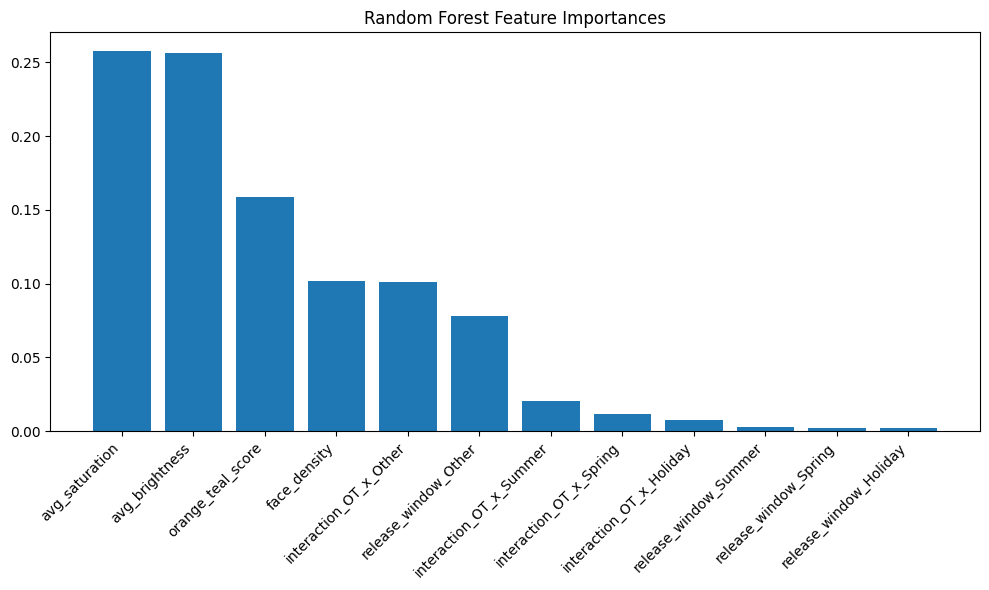

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Train/Test Split (80/20)
# Use the X_scaled (without the statsmodels constant)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Initialize and Train the Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Make Predictions on the Test Set
y_pred = rf_model.predict(X_test)

# 4. Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Random Forest Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# 5. Feature Importance Visualization
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

Predictive modeling statistics

In [8]:
import pandas as pd

print("========== PART 5: PREDICTIVE MODELING STATISTICS ==========")
# 1. Print the exact evaluation metrics
print("Model Performance Metrics:")
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Root Mean Sq Error (RMSE) : {rmse:.4f}")
print(f"R-squared (R2)            : {r2:.4f}\n")

# 2. Extract and format the feature importances
print("Feature Importances (Ranked):")
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Weight': rf_model.feature_importances_
}).sort_values(by='Importance Weight', ascending=False)

# Format as a percentage for easier reading
importance_df['Importance (%)'] = (importance_df['Importance Weight'] * 100).round(2)

print(importance_df[['Feature', 'Importance (%)']].to_string(index=False))

========== PART 5: PREDICTIVE MODELING STATISTICS ==========
Model Performance Metrics:
Mean Absolute Error (MAE) : 2.3820
Root Mean Sq Error (RMSE) : 2.9443
R-squared (R2)            : 0.0528

Feature Importances (Ranked):
                 Feature  Importance (%)
          avg_saturation           25.75
          avg_brightness           25.63
       orange_teal_score           15.84
            face_density           10.21
  interaction_OT_x_Other           10.12
    release_window_Other            7.79
 interaction_OT_x_Summer            2.04
 interaction_OT_x_Spring            1.15
interaction_OT_x_Holiday            0.78
   release_window_Summer            0.27
   release_window_Spring            0.21
  release_window_Holiday            0.20


1. Model Performance (It did worse than the linear model)
R-squared (0.0528): The Random Forest explains only ~5.3% of the variance in global revenue, which is actually worse than the OLS linear regression model (~9.6%). This suggests that adding the non-linear, complex decision logic of a Random Forest did not help predict box office behavior; the simpler linear model generalized better.
MAE (2.3820): On average, the model's prediction is off by 2.38 units on the log scale. Because the target is log-transformed, an error of 2.38 means the model is often miscalculating the actual dollar value by a massive multiple (roughly $10\times$ off the real box office total). This confirms that visual features alone are not enough to reliably predict exact revenue numbers.
2. Feature Importances: The Shift from Timing to Aesthetics
Unlike regression coefficients (which show the direction and magnitude of the relationship), Random Forest's feature importance shows us which variables the algorithm relied heavily on to strictly partition the data. The results show a major flip from the OLS model:

Visuals Dominate: The continuous aesthetic features completely dominated the model's decision-making. Average Saturation (25.75%) and Average Brightness (25.63%) account for over half of total model importance. The algorithm relied on these heavily to slice up the dataset.
Face Density Dropped: Despite having the strongest linear correlation in OLS, face_density only accounts for 10.21% importance here.
Timing was Ignored (Mostly): In the linear model, releasing during the Holiday or "Other" window caused massive swings in predicted revenue. However, the Random Forest essentially ignored the major release windows (Summer, Spring, Holiday each have less than 1% importance).
The "Other" Indicator: The only categorical/timing feature it cared about was release_window_Other (7.79%) and its interaction with Orange/Teal (10.12%). Since "Other" films make up the vast majority of your dataset (~16,000 out of 21,000 films), the model likely used this variable simply to separate massive studio films (which secure major release weekends) from lower-budget indie or direct-to-video films (which get relegated to "Other" months).
Overall Conclusion: While releasing a movie at the right time (like the Holidays) has the highest linear impact on revenue, a machine learning model uses the poster's visual saturation and brightness to categorize and predict the film's financial tier.

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Get predictions from your statsmodels using the full dataset (y)
y_pred_ols = model.predict(X_with_const)
y_pred_interaction = interaction_model.predict(X_interaction_with_const)

# 2. Calculate MAE and RMSE for the Base OLS Model
ols_mae = mean_absolute_error(y, y_pred_ols)
ols_rmse = np.sqrt(mean_squared_error(y, y_pred_ols))

# 3. Calculate MAE and RMSE for the Interaction OLS Model
interaction_mae = mean_absolute_error(y, y_pred_interaction)
interaction_rmse = np.sqrt(mean_squared_error(y, y_pred_interaction))

# 4. Compile the metrics into a dictionary
summary_data = {
    "Model Type": [
        "Base Linear Regression (OLS)", 
        "Interaction Linear Regression (OLS)", 
        "Random Forest Regressor (ML)"
    ],
    "R-Squared": [model.rsquared, interaction_model.rsquared, r2],
    "MAE": [ols_mae, interaction_mae, mae],
    "RMSE": [ols_rmse, interaction_rmse, rmse]
}

# 5. Create a standard DataFrame and round the metrics
summary_df = pd.DataFrame(summary_data)

# Round the numerical columns to 4 decimal places for clean reading
summary_df[["R-Squared", "MAE", "RMSE"]] = summary_df[["R-Squared", "MAE", "RMSE"]].round(4)

print("========== PREDICTIVE MODEL EVALUATION SUMMARY (N ≈ 21,800) ==========")
display(summary_df)


========== PREDICTIVE MODEL EVALUATION SUMMARY (N ≈ 21,800) ==========


,Model Type,R-Squared,MAE,RMSE
0,Base Linear Regression (OLS),0.0957,2.3680,2.8958
1,Interaction Linear Regression (OLS),0.0960,2.3677,2.8953
2,Random Forest Regressor (ML),0.0528,2.3820,2.9443


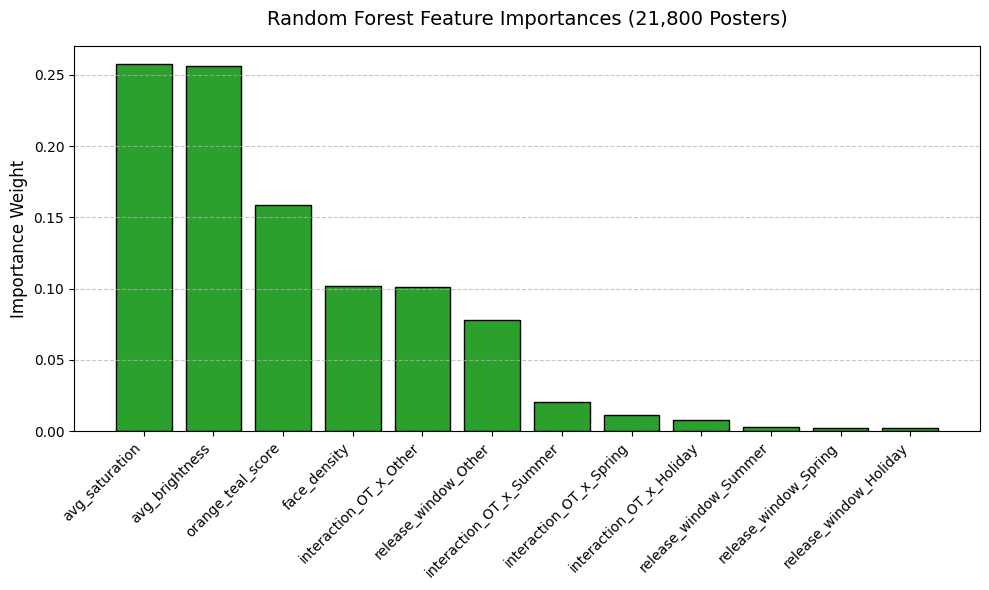

Success! All model summaries, tables, and figures have been saved to the 'final_presentation_outputs' folder.


In [12]:
import os
import matplotlib.pyplot as plt

# Create a dedicated output directory
output_dir = "final_presentation_outputs"
os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------------
# 1. SAVE THE TABLES & SUMMARIES
# ---------------------------------------------------------

# Save the consolidated evaluation table (MAE, RMSE, R-Squared)
summary_df.to_csv(f"{output_dir}/model_evaluation_summary.csv", index=False)

# Save the Random Forest feature importances table
importance_df.to_csv(f"{output_dir}/rf_feature_importances.csv", index=False)

# Save the massive OLS summaries to a clean text file
with open(f"{output_dir}/ols_regression_results.txt", "w") as file:
    file.write("========== BASE OLS REGRESSION (N ≈ 21,800) ==========\n")
    file.write(model.summary().as_text())
    file.write("\n\n\n========== INTERACTION OLS REGRESSION (N ≈ 21,800) ==========\n")
    file.write(interaction_model.summary().as_text())

# ---------------------------------------------------------
# 2. SAVE THE FIGURES & VISUALIZATIONS
# ---------------------------------------------------------

# Ensure 'importances', 'indices', and 'feature_names' are in memory
plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (21,800 Posters)", fontsize=14, pad=15)
plt.bar(range(X_train.shape[1]), importances[indices], align="center", color='#2ca02c', edgecolor='black')
plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.ylabel("Importance Weight", fontsize=12)
plt.xlim([-1, X_train.shape[1]])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot as a high-res PNG
plt.savefig(f"{output_dir}/rf_feature_importance_plot.png", dpi=300, bbox_inches='tight')
plt.show() # Display it in the notebook as well

print(f"Success! All model summaries, tables, and figures have been saved to the '{output_dir}' folder.")
